In [ ]:
!pip uninstall transformers -y
!pip install transformers==4.48.2

## Spiegazione delle features estratte in seguito ad un'analisi del dataset

Prima di impostare il task di classificazione, tramite un'analisi del dataset di training, abbiamo determinato quali features fossero più frequenti nei tweet ironici. Tramite le funzioni presenti in questo blocco, abbiamo, quindi, estratto le singole features per poi modificare il prompt, introducendo un reasoning basato su di esse e guidando il modello nel task di classificazione.

Tra le features estratte vi sono:
- conteggio del numero di lettere maiuscole in realazione al numero di lettere complessivo (escludendo numeri e caratteri speciale), possibile indice di enfasi del concetto espresso;
- presenza di emoji o hashtag identificati come ironici in quanto presenti esclusivamente o quasi in modo esclusivo in tweet annotati come ironici nel dataset di training;
- conteggio del numero di lettere distinte che si ripetono più di due volte all'interno di una parola. Ad esempio nella parola "bellooo" il conteggio vale 1, poiché la lettera "o" viene ripetuta più di 2 volte, mentre nella parola "ciiiaaaaoooo" il conteggio vale 3 in quanto le lettere che si ripetono più di 2 volte sono tre, ovvero "i", "a" ed "o";
- conteggio delle esclamazioni (parole esclamative come "wow", "uh-uh"), possibile indice di sarcasmo e quindi, anche in questo caso, possibile indice di maggiore enfasi presente nel tweet;
- conteggio di pattern esclamativi, ovvero presenza ripetuta di punti esclamativi all'interno del tweet, che possono quindi rafforzare il concetto espresso;
- presenza di frasi tra virgolette e, di conseguenza, di possibili citazioni;
- conteggio di nomi, verbi, aggettivi e avverbi, individuati tramite POS tagging, la cui eccessiva presenza può indicare una maggiore insistenza da parte dell'utente nel voler esprimere un concetto;

In [ ]:
import re
import spacy
import nltk
from collections import Counter
import numpy as np

nlp = spacy.load("en_core_web_sm") 

def count_upper(text):
    count = 0
    count_upper = 0
    for s in text:
        if s.isalpha():
            if s.isupper():
                count_upper +=1
            count += 1
    return count_upper / count if count > 0 else 0.0

def count_extra_char(text):
    repeated_sequences = re.findall(r"(\w)\1{2,}", text)  
    num_repeated_letters = len(repeated_sequences)
    return num_repeated_letters

def clean_repeated_letters(word):
    return re.sub(r'(.)\1{2,}', r'\1', word)

def extract_interjections_spacy(text, max_length=3):

    cleaned_text = " ".join([clean_repeated_letters(word) for word in text.split()])

    doc = nlp(cleaned_text)

    interjections = []
    for token in doc:
        if token.pos_ == "INTJ":
            if len(token.text) <= max_length:
                interjections.append(token.text.capitalize())

    return len(interjections)
    
def extract_features(tweet):
    features = {}

    ################ Features binaria, se è presenta almeno un Emoji o HashTag ironico ##################
    irony_emojis = ["😒", "😑", "😷", "😤", "🙀", "👯", "🍻", "😫", "😳", "😱", "🔫"]
    target_hashtags = ['#ha', '#fml', '#rape', '#uber', '#shocker', '#sonyhack', '#thanksobama', '#gamergate', 
                       '#fb', '#mtvstars', '#happymonday', '#trolls', '#blessed', '#sorrynotsorry', '#cfbplayoff', 
                       '#annoying', '#bbn', '#handsupdontshoot', '#fashion', '#zzzz', '#kashmir', '#cuba', '#lfc', 
                       '#insomnia', '#awesome', '#naah', '#cameronmustgo', '#lifegoals', '#sonakshi', '#security', 
                       '#pissed', '#notfun', '#hypocrites', '#finalsweek', '#billcosby', '#gharwapsi']

    has_ironic_emoji = any(e in tweet for e in irony_emojis)
    has_ironic_hashtag = any(h in tweet.lower() for h in target_hashtags)

    features['emoji_hastag_ironic'] = 1 if has_ironic_emoji or has_ironic_hashtag else 0

    ########## Conto se ci sono caratteri ripetuti più di tre volte ###########
    extra_char_features = count_extra_char(tweet)
    features['extra_char'] = extra_char_features

    ########## Conto Esclamazioni "Wow",  "Oh" ecc. #############
    extra_interjections_features = extract_interjections_spacy(tweet)
    features['extra_interjections'] = extra_interjections_features

    ############## Conto se ci sono pattern esclamativi (Fantastico!!!!!!) ###############
    exclamation_count = len(re.findall(r"!{2,}", tweet))
    features['extra_exclamation_count'] = exclamation_count

    ############ Conto la presenza di Virgolette ############
    quote_count = tweet.count('"')
    features['quote_count'] = quote_count

    ############# con POS tengo il conto di nomi, verbi, aggettivi e avverbi #############
    words = nltk.word_tokenize(tweet) 
    pos_tags = [tag for _, tag in nltk.pos_tag(words)]
    pos_counts = Counter(pos_tags)

    pos_array = np.array([pos_counts.get(tag, 0) for tag in ['NN', 'VB', 'JJ', 'RB']], dtype=np.float32)
    total_words = len(words)
    if total_words > 0:  
        pos_array = pos_array / total_words

    features['type_words'] = pos_array

    return features

## Definizione dell'instruction e della relativa answer

Dovendo addestrare un modello di tipo decoder-only e avendo utilizzato il template già implementato chat-template, abbiamo definito l'instruction dove diamo delle direttive al modello. In particolare, abbiamo definito il tipo di task che il modello dovrà compiere dando anche delle direttive precise su come dovrà essere formata la risposta. Nel caso di presenza di ironia il modello dovrà ripondere con la parola "YES" mentre in assenza di ironia dovrà rispondere con la parola "NO". 
Inoltre, per guidare il modello nella risposta, abbiamo definito la stringa answer dopo la quale il modello dovrà inserire la sua risposta e quindi la classificazione effettiva del tweet. Questa stringa verrà, quindi, utilizzata nella modifica del dataset permettendoci di realizzare un prompt che spinga il modello nell'esecuzione del task di classificazione.

In [3]:
instruction = "Classify the following tweet as ironic or not ironic.\nIf the tweet is ironic, respond with YES.\nIf the tweet is not ironic, respond with NO.\n"
answer = "Based on the reasoning, my classification is: "

## Caricamento dei tre dataset: training, validation e test 

Tramite il blocco sottostante effettuaimo il carimento dei tweet di training, validation e test e le label di training e validation e generiamo i singoli dataset raggruppando i tweet e le relative label in un singolo oggetto

In [ ]:
from datasets import Dataset, DatasetDict

def import_data():
    train_x_path = "/kaggle/input/dataset/datasets/irony/train_text.txt"
    train_y_path = "/kaggle/input/dataset/datasets/irony/train_labels.txt"
    val_x_path = "/kaggle/input/dataset/datasets/irony/val_text.txt"
    val_y_path = "/kaggle/input/dataset/datasets/irony/val_labels.txt"
    test_x_path = "/kaggle/input/dataset/datasets/irony/test_text.txt"


    with open(train_x_path, "r", encoding="utf-8") as f:
        x_train = [line.strip() for line in f]

    with open(train_y_path, "r", encoding="utf-8") as f:
        y_train_numeriche = [int(line.strip()) for line in f]
        y_train = [answer + "YES" if y == 1 else answer+ "NO" for y in y_train_numeriche]

    with open(val_x_path, "r", encoding="utf-8") as f:
        x_val = [line.strip() for line in f]

    with open(val_y_path, "r", encoding="utf-8") as f:
        y_val_numeriche = [int(line.strip()) for line in f]
        y_val = [answer + "YES" if y == 1 else answer + "NO" for y in y_val_numeriche]
    
    with open(test_x_path, "r", encoding="utf-8") as f:
        x_test = [line.strip() for line in f]

    return x_train, y_train, x_val, y_val, y_val_numeriche, x_test

def create_dataset(x_split, y_split=None):
    def my_gen():
        for i in range(len(x_split)):
            data = {
                'instruction': instruction,
                'input': x_split[i],
            }
            if y_split is not None:
                data['textual_label'] = y_split[i]
            yield data
    return Dataset.from_generator(my_gen)
            
x_train, y_train, x_val, y_val, y_val_numeriche, x_test = import_data()

dataset_train = create_dataset(x_train, y_train)
dataset_val = create_dataset(x_val)
dataset_test = create_dataset(x_test)

## Creazione di un dizionario unico 

Raggruppiamo tutti i dataset in un singolo dizionario per semplificarne l'accesso

In [5]:
dataset = DatasetDict({
    "train": dataset_train,
    "val": dataset_val,
    "test": dataset_test
})

## Import delle principali librerie e caricamento del modello e del tokenizer

Nel blocco sottostante importiamo le librerie necessarie per il recupero del modello.
Dopo aver definito la chiave di autenticazione, effettuato il login e definito il nome del modello che verrà utilizzato per questo task di classificazione, tramite la classe AutoModelForCausalLM effettuiamo il download del modello preaddestrato per poi eseguire un finetuning sul nostro dataset e quindi modificare i parametri del modello facendo sì che il modello si specializzi nel task di riconoscimento di ironia

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig
from huggingface_hub import login

model_name = 'meta-llama/Llama-3.2-1B-Instruct'

chiave_di_autenticazione = "key"

login(token=chiave_di_autenticazione)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

## Creazione dell'oggetto LoRAConfig per l'applicazione di un approccio PEFT

Definiamo l'oggetto LoraConfig. Questo ci permette di aggiornare una rappresentazione Low Rank della matrice dei pesi e quindi un numero di parametri ridotto. Questo si traduce in un addestramento più rapido e un utilizzo più efficiente della memoria

In [ ]:
from peft import LoraConfig

lora_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=['q_proj', 'k_proj', 'v_proj'],
    lora_dropout=0.1
)

## Funzione fix_dataset per l'applicazione del chat_template 

Tramite la funzione fix_dataset, alla quale passiamo il dataset prima impostato, creiamo il nuovo dataset contenente i prompt ottenuti applicando il template "chat_template". Tramite questa funzione introduciamo anche il reasoning basato sulle features prima estratte e già descritte sopra.

In [ ]:
from datasets import DatasetDict

def fix_dataset(dataset, tokenizer):
    new_dataset = {}

    for split in dataset:
        complete_input = []

        for i in range(len(dataset[split])):
            features = extract_features(dataset[split]['input'][i])
            tweet = dataset[split][i]['input']
            
            # Reasoning (analisi del tweet):
            reasoning = f"""
                Let's analyze the tweet:
                - Does the tweet include exaggerations or sarcasm?
                - Is there a contradiction or absurdity in the tone of the tweet?
                Based on these signs, we classify the tweet.
            
                Tweet: "{tweet}"
            
                Reasoning:
            """
            
            reasoning += f" The tweet includes the following features: " \
                         f"IRONIC_TAG_EMOJI: {features.get('emoji_hastag_ironic', 'N/A')}, " \
                         f"EXTRA_CHAR: {features.get('extra_char', 'N/A')}, " \
                         f"INTERJECTIONS: {features.get('extra_interjections', 'N/A')}, " \
                         f"EXCLAMATION_PATH: {features.get('extra_exclamation_count', 'N/A')}, " \
                         f"QUOTATION_MARKS: {features.get('quote_count', 'N/A')}, " \
                         f"TAG_NN_VB_JJ_RB: {features.get('type_words', 'N/A')}."
            
            if 'textual_label' in dataset[split].column_names:
                chat_template = tokenizer.apply_chat_template(
                    [
                        {'role': 'system', 'content': dataset[split][i]['instruction']},
                        {'role': 'user', 'content': tweet},
                        {'role': 'assistant', 'content': reasoning},  # Reasoning del modello
                        {'role': 'assistant', 'content': dataset[split][i]['textual_label']} 
                    ],
                    tokenize=False
                )
            else:
                # Se 'textual_label' non è presente, creiamo il template senza
                chat_template = tokenizer.apply_chat_template(
                    [
                        {'role': 'system', 'content': dataset[split][i]['instruction']},
                        {'role': 'user', 'content': tweet},
                        {'role': 'assistant', 'content': reasoning}  # Reasoning del modello
                    ],
                    tokenize=False
                )

            complete_input.append(chat_template)

        new_dataset[split] = dataset[split].add_column("text", complete_input)

    return DatasetDict(new_dataset)

fixed_dataset = fix_dataset(dataset, tokenizer)

Per permettere il funzionamento di SFTTrainer rimuoviamo la versione installata di trl e installiamo la versione 0.12.1

In [ ]:
!pip uninstall -y trl #Necessario altrimenti SFTTrainer non funziona
!pip install trl==0.12.1 -q

## Funzione plot per la creazione dei grafici

Definiamo la funzione di plot che ci permette di verificare l'andamento delle loss e quindi verificare il corretto funzionamento dell'addestramento

In [10]:
import matplotlib.pyplot as plt

def plot_losses():

    logs = trainer.state.log_history
    
    steps = [log["step"] for log in logs if "loss" in log]
    losses = [log["loss"] for log in logs if "loss" in log]
    
    plt.figure(figsize=(10, 6))
    plt.plot(steps, losses, marker='o', linestyle='-', label='Training Loss')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.title('Training Loss Over Time')
    plt.grid(True)
    plt.legend()
    plt.show()


## Implementazione della classe Early Stopping

Nel seguente blocco abbiamo implementato l'early stopping in quanto, avendo avuto diversi problemi relativi alla memoria, che ci ha limitato in alcune esecuzioni, tra cui l'esecuzione della validazione durante l'addestramento, non è stato possibile utilizzare la callback già esistente in quanto non disponiamo della validation loss durante la fase di addestramento. Di conseguenza, abbiamo riportato il codice per una corretta implementazione, ma, a solo scopo didattico, abbiamo deciso di utilizzare le metrica di training loss per la selezione del modello. Nel codice riportato, tramite la funzione on_log, ogni volta che il trainer stampa a schermo le loss calcolate viene attivata l'esecuzione di questa funzione per verificare se è necessario interrompere l'addestramento o continuare.


In [ ]:
from transformers import TrainerCallback

class EarlyStoppingCallback(TrainerCallback):
    def __init__(self, patience=3, min_delta=0.001):
        self.patience = patience         
        self.min_delta = min_delta       
        self.best_loss = float('inf')     
        self.counter = 0                 

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            current_loss = logs["loss"]

            if current_loss + self.min_delta >= self.best_loss :
                self.counter += 1
                if self.counter >= self.patience:
                    print("Early stopping!!!")
                    control.should_training_stop = True
            else:
                self.best_loss = current_loss
                self.counter = 0
            
            print(f"Train Loss: {current_loss:.4f}, Miglior Loss: {self.best_loss:.4f}, Count: {self.counter}")

## Impostazione dei parametri necessari per addestrare il modello, e utilizzo della configurazione LoRAConfig precedentemente citata 

Nel blocco sottostante definiamo i parametri di addestramento del nostro modello. Tra i parametri impostati sono presenti:
- batch_size che indica la dimensione del batch; 
- num_train_epochs che indica il numero di epoche per il quale il modello verrà addestrato, abbiamo utilizzato un numero ridotto di epoche per motivi di tempo e limitazioni di memoria disponibile;
- learning_rate che indica la velocità di addestramento del modello;
- gradient_accumulation_steps che indica il numero di step per i quali verranno accumulati i gradienti prima di effettuare l'aggiornamento dei pesi. Questo permette di simulare l'utilizzo di batch più grandi anche in condizioni di poca memoria disponibile;
- load_best_model_at_end che permette il caricamento del miglior modello ottenuto durante l'addestramento, è stato impostato a False in quanto per motivi di sovraccarico della memoria non è stato possibile effettuare la validazione in fase di training, di conseguenza non è possibile determinare il miglior modello. L'effetto ottenuto ponendo questo parametro a False consiste nel caricare l'ultimo modello ottenuto nell'ultimo step di addestramento;
- evaluation_strategy che indica con quale frequenza validare il modello e quindi calcolare le loss sul dataset di validation;
- save_steps indica ogni quanti step salvare una copia del modello in modo da permettere il successivo recupero dello stesso;
- logging_steps indica ogni quanti step verranno stampate le metriche dell'addestramento tra cui loss di training ed eventuali metriche di validazione nel caso in cui dovesse essere attiva, nel nostro caso verranno stampate soltanto le loss di training;

Oltre a definire i parametri di addestramento definiamo anche l'SFTTrainer con i suoi realtivi parametri, tra i parametri assegnati sono presenti:
- model che indica il modello sul quale verrà effettuato il fine tuning;
- train_dataset che indica il dataset sul quale effettuare il fine tuning;
- peft_config che indica quale strategia di parameter efficient fine tuning verrà utilizzata durante il fine tuning del modello, in questo caso viene utilizzata la tecnica PEFT di LoRA (Low Rank Adaptation);
- dataset_text_field che indica quale colonna del dataset verrà utilizzata per il fine tuning;
- args che indica i parametri di addestramento, ovvero quelli prima definiti tramite TrainingArguments;
- tokenizer che indica il tokenizer che verrà utilizzato dal modello per ottenere i token da fornire allo stesso;
- packing che indica se più sequenze devono essere raggruppate fino a raggiungere la soglia impostata in max_seq_length;
- max_seq_length che indica la lunghezza massima che il modello leggerà in input, nel caso in cui la sequenza fornita dovesse avere una dimensione inferiore a quella impostata questa verrà riempita con un padding in caso contrario la sequenza verrà troncata;
- callback che ci permette di utilizzare l'Early Stopping da noi implementato e precedentemente descritto

Definiti i parametri prima discussi effettuiamo il train tramite la funzione train() dell'oggetto trainer ed infine tramite la funzione precedentemente descritta stampiamo il grafico delle loss del modello

/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '0.13.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.10/dist-packages/transformers/training_args.py:1575: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/trl/trainer/sft_trainer.py:300: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will ove

Map:   0%|          | 0/2862 [00:00<?, ? examples/s]

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Step,Training Loss
50,0.827000
100,0.506200
150,0.481900
200,0.483200
250,0.470600
300,0.459200
350,0.451400
400,0.443200
450,0.480200
500,0.461600


Train Loss: 0.8270, Miglior Loss: 0.8270, Count: 0
Train Loss: 0.5062, Miglior Loss: 0.5062, Count: 0
Train Loss: 0.4819, Miglior Loss: 0.4819, Count: 0
Train Loss: 0.4832, Miglior Loss: 0.4819, Count: 1
Train Loss: 0.4706, Miglior Loss: 0.4706, Count: 0
Train Loss: 0.4592, Miglior Loss: 0.4592, Count: 0
Train Loss: 0.4514, Miglior Loss: 0.4514, Count: 0
Train Loss: 0.4432, Miglior Loss: 0.4432, Count: 0
Train Loss: 0.4802, Miglior Loss: 0.4432, Count: 1
Train Loss: 0.4616, Miglior Loss: 0.4432, Count: 2
Train Loss: 0.4499, Miglior Loss: 0.4432, Count: 3
Train Loss: 0.4335, Miglior Loss: 0.4335, Count: 0
Train Loss: 0.4287, Miglior Loss: 0.4287, Count: 0
Train Loss: 0.4128, Miglior Loss: 0.4128, Count: 0


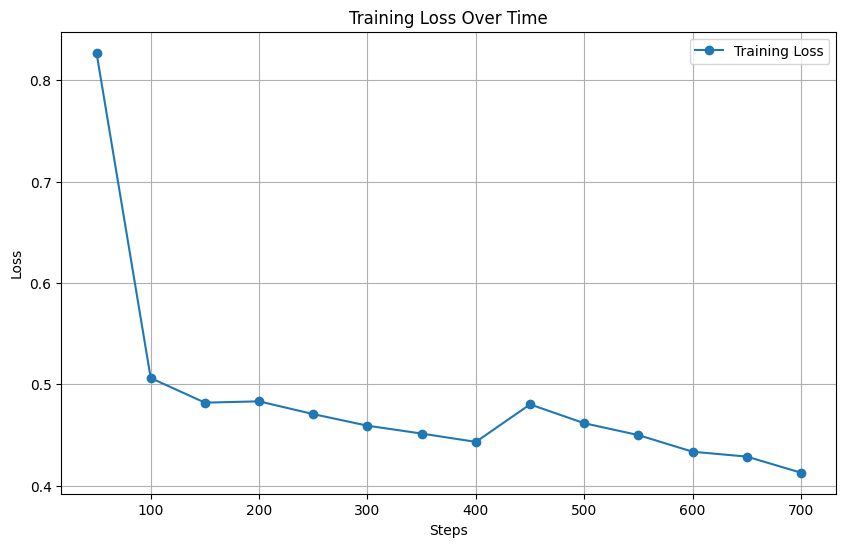

In [ ]:
from transformers import TrainingArguments
from trl import SFTTrainer
import wandb
import torch

wandb.init(mode="disabled")

torch.cuda.empty_cache()
model.gradient_checkpointing_enable()  

tokenizer.pad_token = tokenizer.eos_token

training_args = TrainingArguments(
    output_dir='kaggle/',
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=8,
    learning_rate=1e-3,
    gradient_accumulation_steps=8,
    load_best_model_at_end=False,       
    evaluation_strategy="no",
    save_steps=10,
    logging_steps=50,                  
    report_to=None,
    logging_dir='kaggle/logs',       
)

trainer = SFTTrainer(
    model=model,
    train_dataset=fixed_dataset['train'],
    peft_config=lora_config,
    dataset_text_field="text",
    args=training_args,
    tokenizer=tokenizer,
    packing=False,
    max_seq_length=1024,
    callbacks=[EarlyStoppingCallback(patience=4, min_delta=0.001)]
)

trainer.train()
plot_losses()

Con il blocco sottostante ricaviamo l'ultimo checkpoint salvato in fase di addestramento e carichiamo il modello e il tokenizer per poi effettuare la fase di validazione e di test

In [12]:
import os
from transformers import AutoModelForCausalLM, AutoTokenizer

checkpoint_dir = 'kaggle/'

checkpoints = [os.path.join(checkpoint_dir, d) for d in os.listdir(checkpoint_dir) if d.startswith('checkpoint-')]

checkpoints = sorted(checkpoints, key=lambda x: int(x.split('-')[-1]))

last_checkpoint = checkpoints[-1]
print(f"Ultimo checkpoint trovato: {last_checkpoint}")

model = AutoModelForCausalLM.from_pretrained(last_checkpoint)
tokenizer = AutoTokenizer.from_pretrained(last_checkpoint)


Ultimo checkpoint trovato: kaggle/checkpoint-712


## Funzione ask e descrizione dei parametri impiegati per il suo utilizzo 

Definiamo la funzione ask utile per interagire con il modello in modo tale da poter porre delle domande tramite prompt e ricevere una risposta, in questo caso, contenente la classificazione del tweet.

1. Come prima operazione ricaviamo i token tramite il tokenizer.

2. Successivamente definiamo una GenerationConfig dove impostiamo do_sample e max_new_token.

    Per quanto riguarda do_sample, questo è stato posto a False, il che significa che il modello non effettuerà alcun campionamento sulla distribuzione di probabilità prodotta per la scelta del token successivo. Questo implica che il modello sceglierà sempre la parola con la probabilità più alta rendendo la risposta più deterministica e meno creativa. Abbiamo preso questa scelta poiché il nostro interesse è che il modello classifichi sempre allo stesso modo un tweet fornito più volte, il che è reso più probabile tramite il non utilizzo del campionamento.

    Per quanto riguarda max_new_tokens, questo indica il numero massimo di token che verranno prodotti dal modello. In caso di risposta più lunga questa verrà troncata. E' quindi importante che il suo valore venga scelto con precisione in modo da garantire un corretto funzionamento e una corretta classificazione.

3. Definita la configurazione, generiamo la risposta tramite model.generate() al quale forniamo l'input, la maschera di attenzione e la configurazione prima descritta. La maschera di attenzione, in particolare, serve per guidare il modello su quali token prendere in considerazione e quali no. Questo meccanismo serve anche per gestire la presenza di padding nella sequenza di input.

4. Ottenuta la risposta, tramite tokenizer.batch_decode convertiamo la risposta in un formato leggibile, ovvero passiamo da una lista di id ad una lista di parole. In particolare quello che contiene response prima della decodifica è una lista di id che corrispondono ad indici della matrice di embedding, quindi quello che viene restituito è l'id degli embedding che sono stati generati dal modello.

5. Nelle righe di codice successive alla generazione della risposta e alla decodifica, ci concentriamo sull'estrazione della predizione del modello dalla risposta generata. Avendo dato direttive chiare su come classificare i tweet ironici e non ironici, ovvero imponendo al modello di risponodere con la stringa "YES" in caso di presenza di ironia e "NO" in caso di assenza, quello che facciamo consiste nel cercare all'interno della risposta, tramite un'espressione regolare, la presenza di YES e NO. In base al valore individuato la funzione restituirà "irony" o "not_irony". Questi valori verrano poi confrontati con l'etichetta annotata nel dataset per valutare la bontà del modello. Inoltre abbiamo gestito il caso limite in cui il modello non generi nessuna delle due risposte, classificando quindi il tweet come "unknown"

In [ ]:
def ask(question, model, device):

    tk = tokenizer(question, return_tensors='pt')
    tk['input_ids'] = tk['input_ids'].to(device)
    tk['attention_mask'] = tk['attention_mask'].to(device)

    gen_config = GenerationConfig(
        do_sample=False,
        max_new_tokens=500,
    )
    
    response = model.generate(
        input_ids=tk['input_ids'],
        attention_mask=tk['attention_mask'],
        generation_config=gen_config)
    
    answer = tokenizer.batch_decode(response[:, len(tk['input_ids'][0]):], skip_special_tokens=True)[0]
    print(answer)

    if not answer.strip():
        return response, "unknown", ""  # Ritorna un'etichetta predefinita per risposte vuote

    match = re.search(r'\b(yes|no)\b', answer.lower())

    if match:
        label = match.group(0)
        print(f"Detected Label: {label}")

        if "yes" in label :
            return response, "irony", label
        else:
            return response, "not-irony", label
    else:
        return response, "unknown", ""   

## Gestione della fase di valutazione del modello 

Qui ci occupiamo di effettuare la validazione del modello. Quindi dopo aver ottenuto il dispositivo disponibile sulla macchina carichiamo il modello su di esso. A questo punto impostiamo il modello in modalità eval per garantire un corretto funzionamento e quindi disattivare il calcolo dei gradienti che causerebbero uno spreco di risorse.

Dopo aver impostato correttamente il modello quello che facciamo è iterare l'intero dataset di validation per la costruzione del messaggio da mandare al modello. In quest'ultimo inseriamo l'instruction, necessaria per guidare il modello sul task che dovrà compiere, e il tweet, ovvero sample[\"input\"], che dovrà essere classificato.

Successivamente tramite l'utilizzo della funzione ask definita nel blocco precedente, ricaviamo la risposta del modello e quindi la sua classificazione.

In [ ]:
from tqdm import tqdm
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)


results = []  

model.eval()
with torch.no_grad():
    for idx, sample in enumerate(tqdm(fixed_dataset['val'], desc='validation set')):
        response, label , anwser = ask(sample['text'], model, device)
        results.append(label)
        print(label)

validation set:   0%|          | 1/955 [00:00<10:02,  1.58it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


assistant

Based on the reasoning, my classification is: NO.
Detected Label: no
not-irony


validation set:   0%|          | 2/955 [00:01<08:38,  1.84it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


assistant

Based on the reasoning, my classification is: YES.
Detected Label: yes
irony


validation set:   0%|          | 3/955 [00:01<08:15,  1.92it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

assistant

Based on the reasoning, my classification is: NO.
Detected Label: no
not-irony


validation set: 100%|█████████▉| 954/955 [07:34<00:00,  2.13it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


assistant

Based on the reasoning, my classification is: YES.
Detected Label: yes
irony


validation set: 100%|██████████| 955/955 [07:34<00:00,  2.10it/s]

assistant

Based on the reasoning, my classification is: NO.
Detected Label: no
not-irony


## Print di debug e conversione text-to-int

Nel blocco di codice sottostante, oltre a stampare i valori predetti per verificare il corretto funzionamento del modello, effettuaiamo una conversione delle predizioni da \"irony\" e \"not-irony\" a 1 e 0 per poter confrontare correttamente le predizioni restituite dal modello e le label annotate nel dataset.

In [15]:
val_results = [1 if y == "irony" else 0 for y in results]

print(results)
print(val_results)
print(y_val)
print(y_val_numeriche)


['not-irony', 'irony', 'irony', 'irony', 'irony', 'not-irony', 'not-irony', 'not-irony', 'not-irony', 'not-irony', 'not-irony', 'not-irony', 'not-irony', 'irony', 'not-irony', 'not-irony', 'irony', 'not-irony', 'irony', 'irony', 'irony', 'not-irony', 'irony', 'irony', 'irony', 'not-irony', 'irony', 'irony', 'not-irony', 'not-irony', 'not-irony', 'irony', 'not-irony', 'irony', 'irony', 'irony', 'irony', 'irony', 'not-irony', 'not-irony', 'not-irony', 'irony', 'irony', 'irony', 'irony', 'not-irony', 'not-irony', 'not-irony', 'not-irony', 'not-irony', 'irony', 'irony', 'not-irony', 'not-irony', 'irony', 'irony', 'irony', 'irony', 'irony', 'not-irony', 'irony', 'irony', 'not-irony', 'not-irony', 'not-irony', 'not-irony', 'irony', 'irony', 'not-irony', 'irony', 'not-irony', 'irony', 'not-irony', 'not-irony', 'irony', 'irony', 'irony', 'not-irony', 'irony', 'not-irony', 'not-irony', 'irony', 'irony', 'irony', 'not-irony', 'not-irony', 'not-irony', 'not-irony', 'not-irony', 'not-irony', 'iron

## Generazione e plot delle matrici di confusione

Dovendo valutare la bontà del modello, definiamo la funzione conf_matrix che ci permette di stampare a schermo la matrice di confusione utile per mostrare come vengono classificati i tweet e quindi utile per compredenre dove il modello sbaglia.

Inoltre tramite l'utilizzo della funzione f1_score di sklearn.metrics effettuiamo il calcolo della f1_score macro.

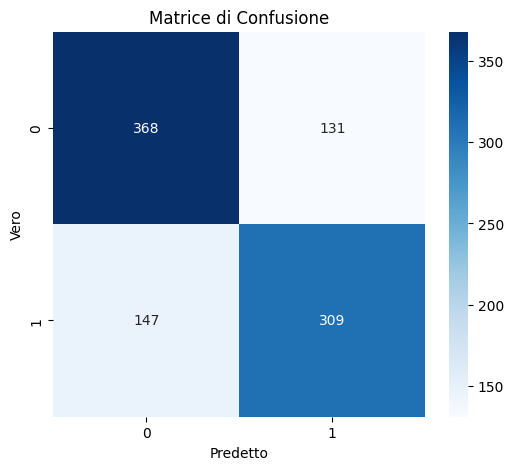

F1 Macro Score: 0.7078


In [16]:
from sklearn.metrics import f1_score
import seaborn as sns
from sklearn.metrics import confusion_matrix


def conf_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predetto")
    plt.ylabel("Vero")
    plt.title("Matrice di Confusione")
    plt.show()
    
f1_macro = f1_score(y_val_numeriche, val_results, average='macro')

conf_matrix(y_val_numeriche, val_results)

print(f'F1 Macro Score: {f1_macro:.4f}')

## Produzione delle label di test 

Una volta effettuate le fasi di training e di validation proseguiamo con la fase di test. 

In questo blocco produciamo le predizioni del modello sul dataset di test. Queste ultime vengono poi salvate in un file csv. Questo file sarà poi utilizzato per verificare tramite la piattaforma foundry l'effettivo punteggio di f1 macro ottenuto sul test. 

In [ ]:
import csv
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

results_test = []

model.eval()
with torch.no_grad():
    for idx, sample in enumerate(tqdm(fixed_dataset['test'], desc='test set')):

        response, label, _ = ask(sample['text'], model, device)
        results_test.append(label)
        print("label", label)

val_results_test = [1 if y == "irony" else 0 for y in results_test]

output_csv_path = f"test_tweet_label.csv"

with open(output_csv_path, mode="w", newline="", encoding="utf-8") as csv_file:
        writer = csv.writer(csv_file)
        for y in val_results_test:
            writer.writerow([y]) 

test set:   0%|          | 1/784 [00:00<06:22,  2.05it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


assistant

Based on the reasoning, my classification is: NO.
Detected Label: no
label not-irony


test set:   0%|          | 2/784 [00:00<06:08,  2.12it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


assistant

Based on the reasoning, my classification is: YES.
Detected Label: yes
label irony


test set:   0%|          | 3/784 [00:01<06:01,  2.16it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


...

assistant

Based on the reasoning, my classification is: YES.
Detected Label: yes
label irony


test set: 100%|█████████▉| 783/784 [06:15<00:00,  2.12it/s]Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


assistant

Based on the reasoning, my classification is: YES.
Detected Label: yes
label irony


test set: 100%|██████████| 784/784 [06:16<00:00,  2.08it/s]

assistant

Based on the reasoning, my classification is: NO.
Detected Label: no
label not-irony


**Uno dei problemi che ci ha maggiormente vincolati è stata la poca memoria fornita da Kaggle e Colab, piattaforme sulle quali abbiamo eseguito il nostro codice. Infatti, abbiamo dovuto limitare le operazioni su di essa. Tra le limitazioni che abbiamo dovuto affrontare, c’è stata l’omissione del calcolo della validation loss durante la fase di Train, che ci ha quindi impedito di implementare correttamente l'early stopping. Di conseguenza siamo stati costretti ad utilizzare come metrica la Train loss.**

Di seguito viene riportato l'errore riscontrato non appena viene attivata anche la validation in fase di training.

![Immagine CudaError](./CudaError.png)
